# Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import geopandas as gpd
from shapely.geometry import Point
import pgeocode

pd.set_option('display.max_columns', None)

senate_general_indiv20 = pd.read_csv('senate_general_indiv20.csv', dtype=str)
senate_general_indiv22 = pd.read_csv('senate_general_indiv22.csv', dtype=str)

display(senate_general_indiv20.head())
display(senate_general_indiv22.head())

,CMTE_ID,IMAGE_NUM,TRANSACTION_TP,NAME,CITY,STATE,ZIP_CODE,EMPLOYER,OCCUPATION,TRANSACTION_DT,TRANSACTION_AMT,CAND_ID,CAND_NAME,CAND_PTY_AFFILIATION,CAND_OFFICE_ST
0,C00647842,202010089285059826,15,"LOMBARDO, ROBERT",MANCHESTER,NH,03102,ELECTRONICS FOR IMAGING INC,TRADE COMPLIANCE MANAGER,2020-09-08,275,S0NH00300,"O'DONNELL, JUSTIN F",LIB,NH
1,C00716340,202010089285059649,15,"FLOYD, WILLIAM",EVANSTON,IL,60201,RETIRED,RETIRED,2020-09-10,500,S0IL00543,"CURRAN, MARK",REP,IL
2,C00716340,202010089285059651,15,"GULLY, MICHAEL",QUINCY,IL,62305,GULLY TRANSPORTATION,TRUCK LINE EXECUTIVE,2020-09-07,1000,S0IL00543,"CURRAN, MARK",REP,IL
3,C00716340,202010089285059651,15,"GULLY, MICHAEL",QUINCY,IL,62305,GULLY TRANSPORTATION,TRUCK LINE EXECUTIVE,2020-09-07,250,S0IL00543,"CURRAN, MARK",REP,IL
4,C00716340,202010089285059661,15,"O'BRIEN, KATHLEEN",LAKE FOREST,IL,60045,SELF,ATTORNEY,2020-09-02,250,S0IL00543,"CURRAN, MARK",REP,IL


,CMTE_ID,IMAGE_NUM,TRANSACTION_TP,NAME,CITY,STATE,ZIP_CODE,EMPLOYER,OCCUPATION,TRANSACTION_DT,TRANSACTION_AMT,CAND_ID,CAND_NAME,CAND_PTY_AFFILIATION,CAND_OFFICE_ST
0,C00588772,202212089547742689,22Y,"MURPHY, PAMELA",STAMFORD,CT,069028004,NaN,NaN,2022-09-16,2900,S6NH00091,"HASSAN, MARGARET WOOD",DEM,NH
1,C00588772,202212089547734268,15,"BRIODY, ELIZABETH",DETROIT,MI,482325170,CULTURAL KEYS LLC,BUSINESS ANTHROPOLOGIST,2022-09-16,200,S6NH00091,"HASSAN, MARGARET WOOD",DEM,NH
2,C00588772,202212089547736565,15E,"WORKMAN, LINDA",NAPERVILLE,IL,605646011,NOT EMPLOYED,NOT EMPLOYED,2022-09-16,50,S6NH00091,"HASSAN, MARGARET WOOD",DEM,NH
3,C00588772,202212089547736566,15E,"FRIEDELL, MORRIS",BERKELEY,CA,947101522,NOT EMPLOYED,NOT EMPLOYED,2022-09-16,1000,S6NH00091,"HASSAN, MARGARET WOOD",DEM,NH
4,C00588772,202212089547739541,15E,"OWENS, NORMAN",EDINA,MN,554102732,UNISYS,IT CONSULTANT,2022-09-16,10,S6NH00091,"HASSAN, MARGARET WOOD",DEM,NH


# Clean and Plot

In [2]:
cleaned = {}

for year, df in {'2020': senate_general_indiv20, '2022': senate_general_indiv22}.items():
    print(f'\n ===== {year} ===== ')

    df = df.copy()  # avoid modifying original

    df['TRANSACTION_AMT'] = df['TRANSACTION_AMT'].astype(float)

    # for log transform - for now only keep POSITIVE donations (consider later)
    pre_rows = len(df)
    df = df.dropna(subset=['TRANSACTION_AMT'])
    print('Rows removed from missing donations: ', pre_rows - len(df))

    pre_rows = len(df)
    df = df[df['TRANSACTION_AMT'] >= 1]
    print('Rows removed from negative/zero donations): ', pre_rows - len(df))

    df['LOG_TRANSACTION_AMT'] = np.log(df['TRANSACTION_AMT'].clip(lower=1))

    # drop missing / faulty zip codes
    pre_rows = len(df)
    df = df.dropna(subset=['ZIP_CODE'])
    print('Rows removed from missingness: ', pre_rows - len(df))

    pre_rows = len(df)
    df = df[~df['ZIP_CODE'].str.contains(r'[a-zA-Z]', na=False)]
    print('Rows removed from letters: ', pre_rows - len(df))

    df['ZIP_CODE'] = df['ZIP_CODE'].where(df['ZIP_CODE'].str.len() != 9, df['ZIP_CODE'].str[:5])

    pre_rows = len(df)
    df = df[df['ZIP_CODE'].str.len() == 5]
    print('Rows removed from not five digits: ', pre_rows - len(df))

    print('Remaining rows: ', len(df))

    df['ZIP_CODE'] = df['ZIP_CODE'].astype(str).str.zfill(5)

    nomi = pgeocode.Nominatim('us')
    geo_info = nomi.query_postal_code(df['ZIP_CODE'].tolist())

    df['LAT'] = geo_info['latitude'].values
    df['LON'] = geo_info['longitude'].values

    cleaned[year] = df  # save cleaned df

# Use cleaned dfs for GeoDataFrames
senate_general_indiv20_gdf = gpd.GeoDataFrame(
    cleaned['2020'],
    geometry=gpd.points_from_xy(cleaned['2020']['LON'], cleaned['2020']['LAT']),
    crs="EPSG:4326"
)

senate_general_indiv22_gdf = gpd.GeoDataFrame(
    cleaned['2022'],
    geometry=gpd.points_from_xy(cleaned['2022']['LON'], cleaned['2022']['LAT']),
    crs="EPSG:4326"
)


 ===== 2020 ===== 
Rows removed from missing donations:  0
Rows removed from negative/zero donations):  15577
Rows removed from missingness:  411
Rows removed from letters:  33
Rows removed from not five digits:  2
Remaining rows:  2216685

 ===== 2022 ===== 
Rows removed from missing donations:  0
Rows removed from negative/zero donations):  21706
Rows removed from missingness:  113
Rows removed from letters:  0
Rows removed from not five digits:  2
Remaining rows:  1995707


In [3]:
# log transform - for now only keep POSITIVE donations (consider later)

pre_rows = len(df)
df['LOG_TRANSACTION_AMT'] = np.log(df['TRANSACTION_AMT'].clip(lower=1))
df = df.dropna(subset=['LOG_TRANSACTION_AMT'])
print('Rows removed from failed log transform (negative/zero value): ', pre_rows - len(df))

Rows removed from failed log transform (negative/zero value):  0


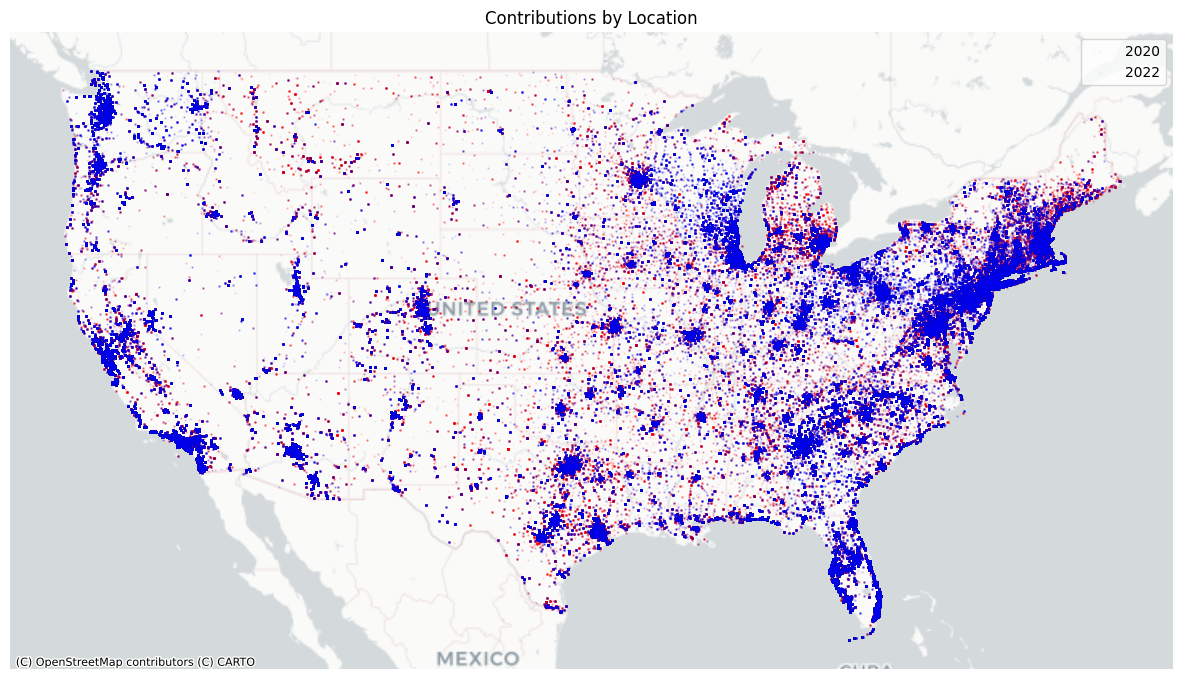

In [4]:
# takes like 30s to run

import contextily as cx
import matplotlib.pyplot as plt

# Project to Web Mercator (required for contextily basemaps)
senate_general_indiv20_gdf_web = senate_general_indiv20_gdf.to_crs(epsg=3857)
senate_general_indiv22_gdf_web = senate_general_indiv22_gdf.to_crs(epsg=3857)

# Clip to continental US
senate_general_indiv20_gdf_web = senate_general_indiv20_gdf_web.cx[-14000000:-7000000, 2500000:6500000]
senate_general_indiv22_gdf_web = senate_general_indiv22_gdf_web.cx[-14000000:-7000000, 2500000:6500000]

fig, ax = plt.subplots(figsize=(15, 10))
senate_general_indiv20_gdf_web.plot(ax=ax, markersize=0.5, color='red', alpha=0.05, label='2020')
senate_general_indiv22_gdf_web.plot(ax=ax, markersize=0.5, color='blue', alpha=0.05, label='2022')
cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_axis_off()
ax.legend()
plt.title("Contributions by Location")
plt.show()

# Replicating Byers, Gill

Implements the following basic structure:

    

In [5]:
# pseudocode

# params = np.zeros(B)

# for b = 1,...,B:
#     sample = df.sample_without_replacement(n)
#     model = fit_geospatial_model(sample)
#     params[b] = model.get_params()

# final_estimate = np.mean(params, axis=0)

In [6]:
# libraries

from pykrige.ok import OrdinaryKriging
from pykrige.uk import UniversalKriging

## a. BASIC CASE: Ordinary Kriging (No Covariates) on NorCal Only

Focus on 2020 data.

2020 NorCal donors: 128035


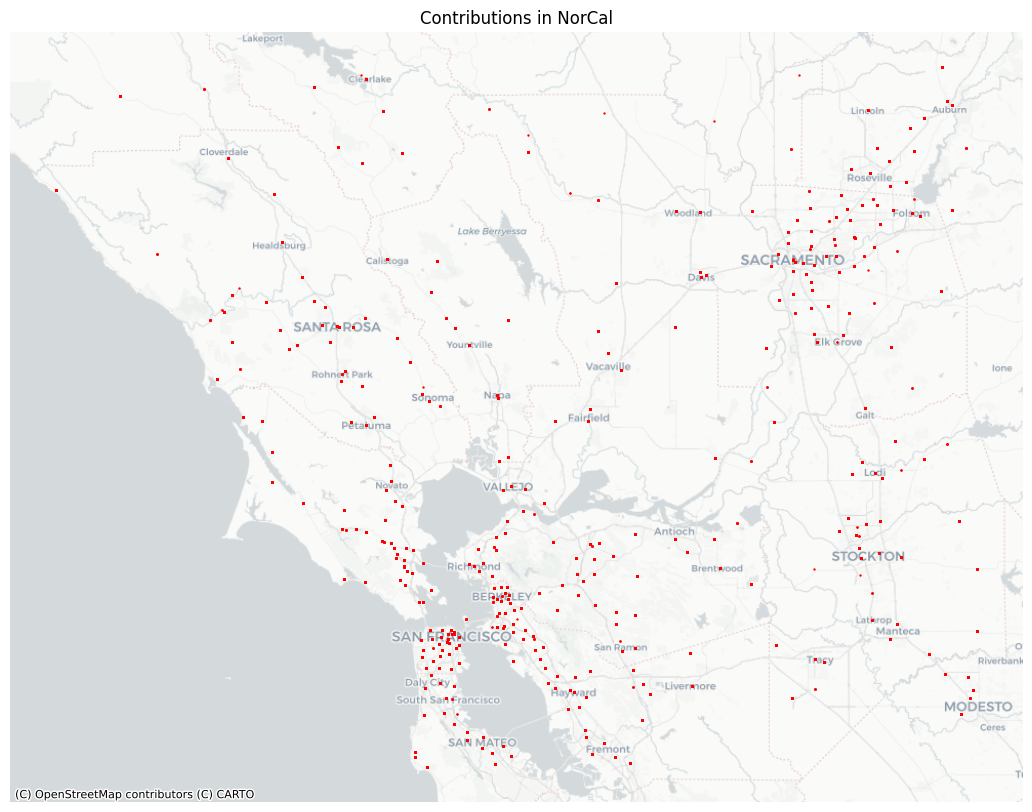

In [12]:
# create smaller sample

def filter_norcal(df):
    mask = (
        (df['LAT'] > 37.5) & 
        (df['LAT'] < 39.0) & 
        (df['LON'] > -123.5) &
        (df['LON'] < -121.0)  
    )
    return df[mask]

norcal_sample = filter_norcal(senate_general_indiv20_gdf).reset_index(drop=True)

print(f"2020 NorCal donors: {len(norcal_sample)}")


# ----- Plot to make sure it worked -----

fig, ax = plt.subplots(figsize=(15, 10))

# reproject to Web Mercator for contextily
norcal_web = norcal_sample.to_crs(epsg=3857)
norcal_web.plot(ax=ax, markersize=0.5, color='red')

cx.add_basemap(ax, source=cx.providers.CartoDB.Positron)

ax.set_axis_off()
plt.title("Contributions in NorCal")
plt.show()

NOTE: the cell below crashed my kernel twice. leaving it to demonstrate that 140k data points is too many.

In [8]:
# # fit ordinary kriging model 
# # based off of this youtube tutorial:
# # https://www.youtube.com/watch?v=mhveiX_d9Q8

# latitude = norcal_sample['LAT']
# longitude = norcal_sample['LON']
# log_transaction_amt = norcal_sample['LOG_TRANSACTION_AMT']

# # define a grid for interpolation
# gridx = np.linspace(min(longitude) - 0.3, max(longitude) + 0.3)
# gridy = np.linspace(min(latitude) - 0.3, max(latitude) + 0.3)

# # use ordinary kriging with a spherical variogram model
# OK = OrdinaryKriging(longitude,
#                      latitude,
#                      log_transaction_amt,
#                      variogram_model='spherical',
#                      coordinates_type='geographic', # accounts for curvature of earth
#                      verbose=True,
#                      enable_plotting=True)
# z_interp, ss = OK.execute('grid', gridx, gridy)

Remedy: Bootstrap approach. First, test on a single random sample of n=100 data points. 

Plotting Enabled

Initializing variogram model...
Coordinates type: 'geographic' 

Using 'spherical' Variogram Model
Partial Sill: 0.3765886774819285
Full Sill: 2.235282393524792
Range: 0.08270509538142712
Nugget: 1.8586937160428636 



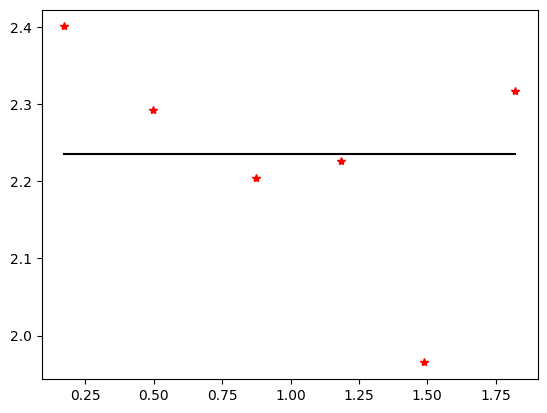

Calculating statistics on variogram model fit...
Executing Ordinary Kriging...



In [ ]:
# ----- create random sample of n=1000 -----
np.random.seed(100)

n = 1000

latitude = norcal_sample['LAT']
longitude = norcal_sample['LON']
log_transaction_amt = norcal_sample['LOG_TRANSACTION_AMT']

idx = np.random.choice(len(norcal_sample), size=n, replace=False)
lat_b = latitude[idx]
lon_b = longitude[idx]
log_transaction_amt_b = log_transaction_amt[idx]

# ----- fit model -----

# define a grid for interpolation
gridx = np.linspace(min(longitude) - 0.3, max(longitude) + 0.3)
gridy = np.linspace(min(latitude) - 0.3, max(latitude) + 0.3)

# use ordinary kriging with a spherical variogram model
OK = OrdinaryKriging(lat_b,
                     lon_b,
                     log_transaction_amt_b,
                     variogram_model='spherical',
                     coordinates_type='geographic', # accounts for curvature of earth
                     verbose=True,
                     enable_plotting=True)
z_interp, ss = OK.execute('grid', gridx, gridy)

Flat line indicates no pattern (mostly noise, not spatial correlation). Bumping to n=5000 before making any conclusions.

Plotting Enabled

Initializing variogram model...
Coordinates type: 'geographic' 

Using 'spherical' Variogram Model
Partial Sill: 0.9929804061795712
Full Sill: 2.151077697577119
Range: 0.18699204639928246
Nugget: 1.1580972913975478 



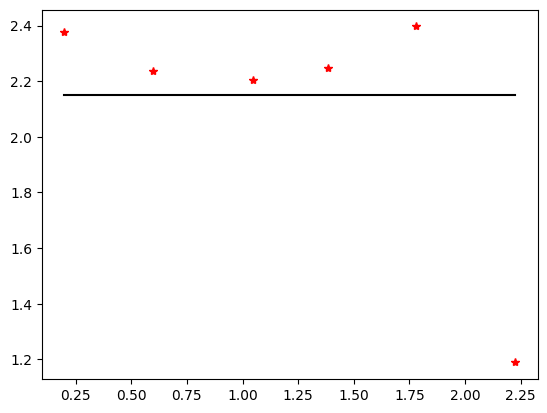

Calculating statistics on variogram model fit...
Executing Ordinary Kriging...



In [15]:
# ----- create random sample of n=5000 -----
np.random.seed(100)

n = 5000

latitude = norcal_sample['LAT']
longitude = norcal_sample['LON']
log_transaction_amt = norcal_sample['LOG_TRANSACTION_AMT']

idx = np.random.choice(len(norcal_sample), size=n, replace=False)
lat_b = latitude[idx]
lon_b = longitude[idx]
log_transaction_amt_b = log_transaction_amt[idx]

# ----- fit model -----

# define a grid for interpolation
gridx = np.linspace(min(longitude) - 0.3, max(longitude) + 0.3)
gridy = np.linspace(min(latitude) - 0.3, max(latitude) + 0.3)

# use ordinary kriging with a spherical variogram model
OK = OrdinaryKriging(lat_b,
                     lon_b,
                     log_transaction_amt_b,
                     variogram_model='spherical',
                     coordinates_type='geographic', # accounts for curvature of earth
                     verbose=True,
                     enable_plotting=True)
z_interp, ss = OK.execute('grid', gridx, gridy)

Verdict: Donation *amount* is not exhibiting spatial structure. Considering *counts* of donations per zip code instead. **TO-DO**